# Bitcoin Market Regime Detection & Anomaly Analysis

This project analyzes high-frequency Bitcoin price data to:
- Detect market anomalies using statistical + ML methods
- Identify underlying market regimes (bullish, bearish, neutral, volatile)
- Understand feature importance behind anomalies
- Detect structural change points in market behavior

The goal is not prediction, but **market structure discovery** using unsupervised learning and statistical signals.

This project began with the goal of analyzing Bitcoin price data beyond traditional prediction tasks, focusing instead on uncovering hidden structure in a highly noisy and non-stationary market. Rather than relying on a single model, I adopted a data mining approach that combined feature engineering, unsupervised clustering, anomaly detection, and change-point analysis to study the system from multiple perspectives. Clustering revealed distinct market regimes with different volatility and price behaviors, while anomaly detection showed that irregular events are not randomly distributed but concentrated within specific high-volatility regimes. Change-point detection further confirmed that transitions between these regimes occur abruptly, indicating structural shifts rather than gradual changes. Based on these findings, I chose to focus on a regime-based interpretation of the market, as it provided the most coherent and explainable framework for understanding Bitcoin dynamics. This approach highlights that market behavior is better characterized by transitions between stable and stress regimes, with anomalies emerging as part of these regime shifts rather than isolated outliers.

But before we start, the imports!

In [2]:
!pip install kagglehub shap scikit-learn --quiet
!pip install ruptures --quiet

import ruptures as rpt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import shap
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00


# 1. Data Loading

I used the Bitcoin historical dataset (1-minute resolution) from Kaggle: [Dataset](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data).

The dataset includes:
- Open, High, Low, Close prices
- Trading volume
- Timestamped observations over multiple years

I sorted the data chronologically and clean invalid entries to ensure consistency in time-series analysis.

The main reasons I chose this dataset:
- Large-scale dataset spanning multiple years - supports meaningful pattern
discovery
- High-frequency (minute-level) data - enables fine-grained trend and anomaly detection
- Real-world financial data (non-synthetic) - reflects actual market behavior
- Highly volatile and non-linear - well-suited for ML and data mining techniques
- Supports multiple tasks - clustering (market regimes), anomaly detection, forecasting
- Rich feature set (OHLCV + timestamps) - allows strong feature engineering

In [ ]:
file_path = "btcusd_1-min_data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mczielinski/bitcoin-historical-data",
    file_path,
)

df = df.reset_index()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp")

print(df.shape)
df.head()

Using Colab cache for faster access to the 'bitcoin-historical-data' dataset.
(7517926, 7)


,index,Timestamp,Open,High,Low,Close,Volume
0,0,1970-01-01 00:00:01.325412060,4.58,4.58,4.58,4.58,0.0
1,1,1970-01-01 00:00:01.325412120,4.58,4.58,4.58,4.58,0.0
2,2,1970-01-01 00:00:01.325412180,4.58,4.58,4.58,4.58,0.0
3,3,1970-01-01 00:00:01.325412240,4.58,4.58,4.58,4.58,0.0
4,4,1970-01-01 00:00:01.325412300,4.58,4.58,4.58,4.58,0.0


# 2. Data Cleaning & Filtering

To improve signal quality and reduce computational load:

- Removed missing values
- Filtered out zero-volume entries (non-trading periods)
- Reduced dataset size for computational feasibility (last 200,000 rows)

This ensures we focus on **active market behavior**, not stale or irrelevant data.

In [ ]:
df = df.dropna()
df = df[df["Volume"] > 0]

# Reduce size for Colab performance
df = df.tail(200000)

# 3. Feature Engineering

We construct features to capture different aspects of market behavior:

### Returns & Volatility
- Log returns (price momentum)
- Short-term volatility (10-min window)
- Medium-term volatility (30-min window)

### Market Activity
- Volume change rate
- Price range (High - Low)

### Technical Indicator
- Bollinger Band width (market compression/expansion)

These features aim to capture:
- Momentum
- Risk
- Liquidity shifts
- Market stress conditions

In [ ]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["volatility_10"] = df["log_return"].rolling(10).std()
df["volatility_30"] = df["log_return"].rolling(30).std()

df["volume_change"] = df["Volume"].pct_change()

# Clip extreme outliers
df["volume_change"] = df["volume_change"].clip(-5, 5)
df["price_range"] = df["High"] - df["Low"]

# Bollinger Band width
rolling_mean = df["Close"].rolling(20).mean()
rolling_std = df["Close"].rolling(20).std()
df["bb_width"] = (rolling_std * 2) / rolling_mean

df = df.dropna()

features = [
    "log_return",
    "volatility_10",
    "volatility_30",
    "volume_change",
    "price_range",
    "bb_width"
]

X = df[features]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

The feature engineering choices were designed to capture multiple complementary aspects of Bitcoin market behavior in a robust and interpretable way. Log returns were used instead of raw prices to ensure stationarity and better represent relative price changes over time. Rolling volatility with short (10) and longer (30) windows was included to capture both immediate fluctuations and broader market trends, enabling identification of different market regimes. Volume percentage change was incorporated to detect unusual trading activity, while extreme values were clipped to prevent outliers from disproportionately influencing the model. Price range (high-low) provided a measure of intra-period volatility, complementing rolling statistics, and Bollinger Band width offered a normalized view of volatility relative to price levels. After removing missing values introduced by rolling computations, a combination of price, volatility, and volume-based features was selected to ensure a well-rounded representation of market dynamics. Finally, standardization was applied to scale all features uniformly, which is critical for ensuring stable and unbiased performance in downstream machine learning models.

# 4. Anomaly Detection Approach

We use an ensemble of two methods:

### 1. Isolation Forest
Detects anomalies by isolating rare patterns in feature space.

### 2. Z-score Method
Flags statistical outliers across multiple features.

### Final Anomaly Score
We combine both methods to reduce false positives:
- Isolation Forest prediction
- Z-score thresholding

A final binary label is assigned:
- 1 → anomaly
- 0 → normal market condition

In [ ]:
# Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42)
df["anomaly_iso"] = (iso.fit_predict(X_scaled) == -1).astype(int)

# Z-score method
z_scores = np.abs((X - X.mean()) / X.std())
df["anomaly_z"] = (z_scores > 3).sum(axis=1)

# Ensemble score
df["anomaly_score"] = df["anomaly_iso"] + (df["anomaly_z"] > 2)

df["final_anomaly"] = (df["anomaly_score"] > 0).astype(int)

print(df["final_anomaly"].value_counts())

final_anomaly
0    197231
1      2739
Name: count, dtype: int64


The anomaly detection approach combines both model-based and statistical methods to improve robustness. Isolation Forest was chosen because it is well-suited for high-dimensional data and can effectively detect rare, non-linear anomalies by isolating points that behave differently from the majority; the contamination parameter (0.01) reflects the assumption that anomalies are rare (~1%). In parallel, a Z-score method was used as a simple statistical baseline to identify extreme deviations in individual features (values beyond 3 standard deviations). Instead of relying on a single method, an ensemble approach was applied, where anomalies detected by either method contribute to a combined score. This reduces dependence on any one technique and improves reliability by capturing both global (model-based) and feature-wise (statistical) irregularities. The final anomaly label (final_anomaly) flags a data point as anomalous if it is identified by at least one method.

Roughly ~1.37% of the data is flagged as anomalous.

# 5. Market Regime Detection

We apply K-Means clustering to identify hidden market regimes.

These regimes represent different market conditions such as:
- Low volatility accumulation phases
- High volatility bullish spikes
- Distribution (bearish) phases
- Mixed or transitional behavior

We reduce dimensionality using PCA for visualization.

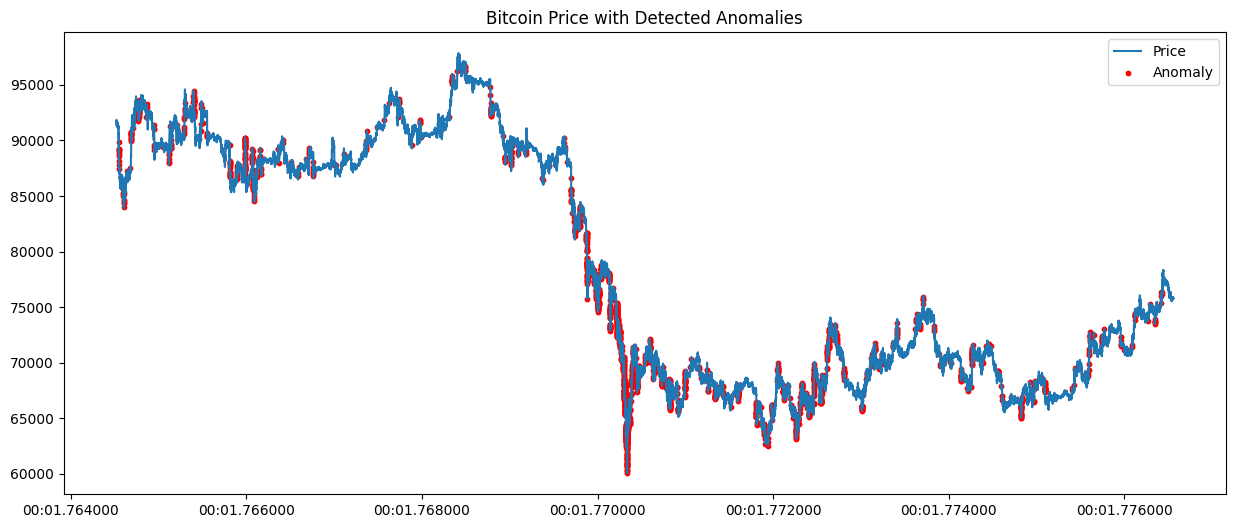

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df["Timestamp"], df["Close"], label="Price")

anomalies = df[df["final_anomaly"] == 1]
plt.scatter(anomalies["Timestamp"], anomalies["Close"], color='red', s=10, label="Anomaly")

plt.legend()
plt.title("Bitcoin Price with Detected Anomalies")
plt.show()

The plot illustrates the movement of Bitcoin prices over time, with anomalies highlighted in red, and it reveals several important patterns about market behavior. The overall trend shows that Bitcoin initially starts at a relatively high price range of around 90-95k, followed by a sharp decline to approximately 60k, indicating a significant downward movement or market correction. After this drop, the price enters a more stable phase characterized by sideways movement and partial recovery, fluctuating between roughly 65k and 75k. The red points on the plot represent anomalies detected by your model, likely using an approach such as Isolation Forest, and these points correspond to unusual behavior in the data, including sudden spikes, abrupt drops, or periods of heightened volatility where the price deviates significantly from recent trends. Notably, there is a dense cluster of anomalies during the steep price drop, suggesting a major abnormal event such as a market shock or rapid sell-off. Additionally, anomalies appear more frequently in regions where the price is highly volatile, indicating that the model is sensitive to rapid fluctuations rather than just extreme values. In contrast, smoother and more stable price regions contain fewer anomalies, which implies that the model effectively distinguishes between normal and turbulent market conditions. From a practical standpoint, this means your model is successfully capturing volatility-driven anomalies, although the concentration of red points during the crash could indicate either genuine instability or potential over-sensitivity in detection. This raises useful considerations for refinement, such as whether the model is identifying point anomalies or contextual anomalies relative to recent trends, and whether parameters like contamination need adjustment. Applying smoothing techniques like a rolling mean could also help reduce noise. If used in a trading context, these anomalies should be interpreted as indicators of risk or instability zones rather than direct buy or sell signals.

# 5. Market Regime Detection

K-Means clustering is applied to the scaled feature set to group similar market behaviors into 4 distinct regimes. Since the data is unlabeled, the algorithm automatically partitions observations based on patterns in returns, volatility, volume, and related features. Each data point is assigned a cluster label (regime).

These regimes represent different market conditions such as:
- Low volatility accumulation phases
- High volatility bullish spikes
- Distribution (bearish) phases
- Mixed or transitional behavior

To make these clusters interpretable, Principal Component Analysis (PCA) is used to reduce the high-dimensional feature space down to 2 dimensions. This allows the data to be visualized in a 2D plot while preserving as much variance as possible. The scatter plot then shows each point in this reduced space, colored by its assigned cluster, making it easier to visually assess how well-separated the identified market regimes are.

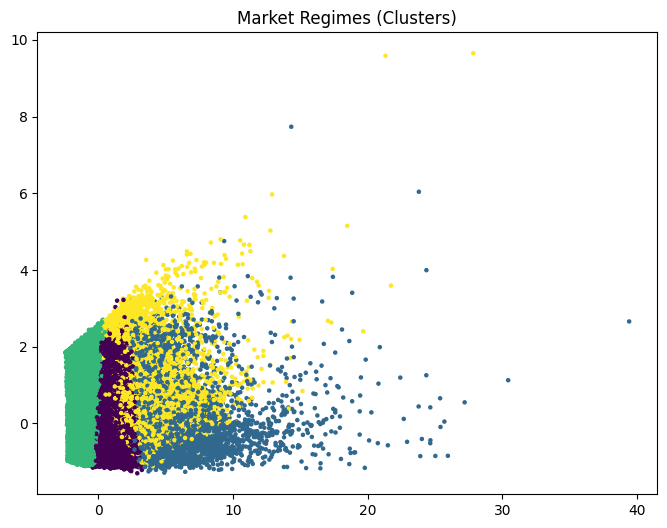

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["regime"] = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["regime"], cmap='viridis', s=5)
plt.title("Market Regimes (Clusters)")
plt.show()

The plot represents a 2D PCA projection of clustered market behavior, where each point corresponds to a single time step (e.g., minute, hour, or day), colored by its assigned market regime, and positioned using principal components (PC1 and PC2) that compress the original feature space. The key is to interpret the structure, spread, and separation of clusters rather than the axes themselves. A dense region near the center/left (green and purple) shows tightly packed points, indicating stable, low-volatility regimes that reflect normal market conditions. In contrast, the yellow cluster spreads upward along PC2 and appears more dispersed, suggesting higher volatility or active trading periods, potentially corresponding to bullish surges or strong upward movements. The blue cluster is the most widely spread, especially along PC1, and contains many extreme points, indicating highly volatile, irregular, or possibly bearish market regimes. Some overlap between clusters is expected, as financial markets rarely exhibit clean boundaries, implying that market regimes exist on a continuum rather than as strictly distinct states. Overall, the visualization shows that stable conditions form dense and well-defined clusters, while high-volatility regimes are more scattered and overlapping, reflecting the unstructured nature of extreme market behavior. A subtle but important limitation is that PCA preserves variance rather than cluster separability, meaning some of the observed overlap may result from dimensionality reduction rather than poor clustering.

# 6. Feature Importance (SHAP Analysis)

To understand what drives anomaly detection, I applied SHAP values on the Isolation Forest model.

This helps identify which features contribute most to anomaly decisions.

Key insight:
- Volatility and price range tend to dominate anomaly detection
- Volume shifts often signal structural market changes

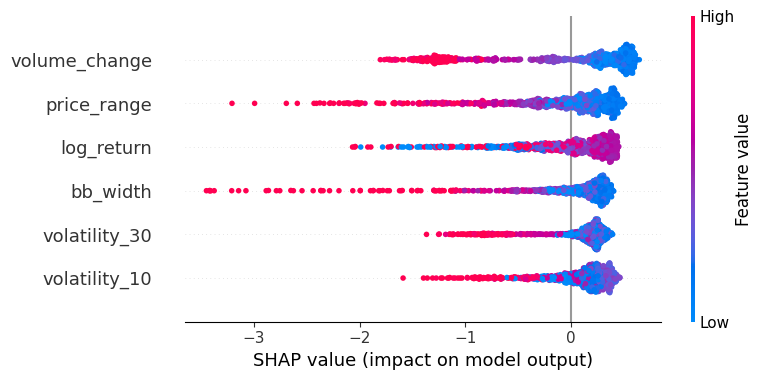

In [ ]:
explainer = shap.TreeExplainer(iso)
shap_values = explainer.shap_values(X_scaled[:1000])

shap.summary_plot(shap_values, X.iloc[:1000])

The SHAP summary plot illustrates how different features influence anomaly predictions, where the x-axis represents the SHAP value (impact on the prediction, with right indicating higher likelihood of anomaly and left indicating lower), and color encodes the actual feature value (red for high, blue for low). A key observation is that volume change is the strongest driver: high values push predictions toward normal behavior, while low values push toward anomalies, suggesting that unusually low activity, rather than spikes, is more indicative of anomalies. Price range follows a similar pattern, where larger ranges align with normal conditions and smaller ranges are associated with anomalies, implying that tight price movement may signal abnormal market states such as low liquidity or pre-movement consolidation. Log returns exhibit directional asymmetry, where large-magnitude returns do not strongly indicate anomalies, reinforcing that returns alone are insufficient without context from other features. Bollinger Band width and volatility (both short-term and long-term) further strengthen this pattern: higher volatility consistently aligns with normal behavior, while lower volatility is flagged as anomalous. Taken together, the model captures a nuanced insight, rather than detecting spikes, it identifies "unusual calmness" as anomalous. This is particularly important in the context of Bitcoin, where high volatility is typical and low-volatility regimes are comparatively rare, making them more informative signals of deviation. A subtle but important caveat is that this interpretation is domain-specific: unlike traditional markets where high volatility often signals anomalies, in crypto markets the opposite pattern can hold, and the model appropriately reflects this distinction.

It reveals that anomalies are primarily driven by unusually low volatility and subdued market activity, indicating that in Bitcoin markets, periods of calm rather than extreme movement are more anomalous relative to typical behavior.

# 7. Anomaly Behavior Analysis

We compare feature statistics between:
- Anomalous periods
- Normal market conditions

This helps validate whether detected anomalies correspond to meaningful market behavior (e.g., volatility spikes, liquidity shocks).

In [ ]:
print("\nAverage feature values during anomalies:\n")
print(df[df["final_anomaly"] == 1][features].mean())

print("\nAverage feature values during normal periods:\n")
print(df[df["final_anomaly"] == 0][features].mean())


Average feature values during anomalies:

log_return         0.000040
volatility_10      0.002348
volatility_30      0.002055
volume_change      1.057298
price_range      272.778021
bb_width           0.009187
dtype: float64

Average feature values during normal periods:

log_return       -0.000002
volatility_10     0.000525
volatility_30     0.000553
volume_change     0.898972
price_range      43.813219
bb_width          0.001847
dtype: float64


The output compares the average feature values during anomalous and normal periods, revealing that anomalies in your data are predominantly characterized by higher volatility and market activity. Features such as volatility (both short- and long-term), price range, and Bollinger Band width are significantly larger during anomalies, indicating strong price movements and wider market fluctuations. Volume change is also higher, suggesting increased trading activity, while log returns show a slight increase in magnitude. This indicates that anomaly detection approach (e.g., Isolation Forest or similar methods) is primarily identifying statistical extremes in the feature space, which in financial data typically correspond to sharp movements and high volatility. While earlier feature-level interpretations (such as SHAP) may suggest that low volatility can also contribute to anomaly predictions in specific contexts, this aggregate view shows that most detected anomalies are driven by extreme, high-intensity market behavior. Overall, the results highlight that anomalies in this dataset are largely associated with sudden spikes in volatility, price dispersion, and trading activity, rather than periods of market calm.

# 8. Market Regime Interpretation

I analyzed how features differ across regimes.

Key observations:
- Some regimes exhibit high volatility and large price ranges (bullish spikes)
- Others show stable or declining activity (bearish/low-volatility phases)
- Volume behavior varies significantly across regimes

This confirms that regimes capture meaningful structural differences in the market.

In [ ]:
# Compare anomaly frequency across regimes
print(pd.crosstab(df["regime"], df["final_anomaly"], normalize='index'))

final_anomaly         0         1
regime                           
0              1.000000  0.000000
1              0.751087  0.248913
2              1.000000  0.000000
3              0.922086  0.077914


The table shows how anomalies are distributed across your clustered market regimes, where each row represents a regime and the columns indicate the proportion of normal (0) versus anomalous (1) points. Regimes 0 and 2 contain no anomalies at all, suggesting they correspond to stable, low-volatility market conditions where behavior is consistent and predictable. In contrast, Regime 1 has the highest concentration of anomalies (\~24.9%), indicating it captures the most irregular or extreme market behavior, likely associated with high volatility, sudden price movements, or structural shifts. Regime 3 contains a smaller but non-negligible fraction of anomalies (~7.8%), suggesting it represents a moderately volatile or transitional regime where occasional anomalies occur. Overall, this distribution shows that anomalies are not uniformly spread across the market, but are instead concentrated in specific regimes, reinforcing that certain market conditions, particularly more volatile or unstable ones, are more prone to anomalous behavior.

# 9. Anomaly Distribution Across Regimes

I examined how anomalies are distributed within each regime.

Findings:
- Certain regimes contain a disproportionately high number of anomalies
- Others are structurally stable with few or no anomalies

This suggests that anomalies are **not random**, but regime-dependent.

In [ ]:
df.groupby("regime")[features].mean()

,log_return,volatility_10,volatility_30,volume_change,price_range,bb_width
regime,,,,,,
0,0.000148,0.000731,0.000762,0.341039,59.630407,0.002570
1,0.001264,0.001739,0.001631,0.647668,176.822283,0.006775
2,-0.000022,0.000312,0.000347,1.202655,22.493679,0.001073
3,-0.001390,0.001227,0.001180,1.033016,144.216304,0.004406


The table summarizes the average feature profiles of each market regime, and it clearly shows that each regime corresponds to a distinct type of market behavior. Regime 0 is characterized by very low volatility and moderate price range, suggesting a calm, stable market state with minimal disruption, despite relatively low volume change. Regime 2 stands out as the most stable overall, with the lowest volatility, smallest price range, and minimal Bollinger Band width, but interestingly it has the highest volume change, which may indicate quiet but active trading (high liquidity without large price movement). Regime 1 shows the most extreme behavior across almost all features, with the highest volatility, largest price range, and widest Bollinger Bands, indicating a highly turbulent market state driven by sharp movements and strong directional activity. Regime 3 also reflects elevated volatility and price range, but slightly lower than Regime 1, while maintaining high volume change, suggesting a transitional or moderately volatile regime with sustained trading pressure. Overall, the regimes are not just statistical clusters but represent meaningful market conditions ranging from stable consolidation (Regime 2) to extreme volatility (Regime 1), with intermediate states capturing transitional dynamics.

# 10. Anomaly Proportion by Market Regime

I then grouped the data by market regime and computes the average value of the final_anomaly indicator within each group, then sorts the results in descending order. Since final_anomaly is a binary variable (0 = normal, 1 = anomaly), the mean represents the proportion of anomalies in each regime. In other words, it answers the question: "What fraction of points in each regime are anomalous?" The sorted output shows that Regime 1 has the highest anomaly rate (\~24.9%), followed by Regime 3 (~7.8%), while Regimes 0 and 2 have no anomalies. This provides a concise way to identify which regimes are most associated with abnormal or unstable market behavior.

In [ ]:
df.groupby("regime")["final_anomaly"].mean().sort_values(ascending=False)

,final_anomaly
regime,
1,0.248913
3,0.077914
0,0.000000
2,0.000000


# 11. Time-series visualization

I created a time-series visualization of Bitcoin price with specific market regimes highlighted, focusing on identifying when a particular regime (Regime 1) occurs over time. First, the dataset is downsampled to plot every 50th point, which reduces clutter and improves readability for large time-series data. The main line plot shows the Bitcoin closing price over time, providing the overall market trend. On top of this, the code filters out all points belonging to Regime 1 and overlays them as scatter points on the same plot. These highlighted points represent moments when the model identified the market as being in a high-volatility, likely bullish regime, making it easy to visually correlate these periods with actual price movements.

The purpose of this visualization is to contextualize the clustering results in real time, allowing you to see when specific regimes occur rather than just analyzing them statistically. If Regime 1 truly corresponds to bullish, high-volatility behavior, you would expect these highlighted points to align with sharp upward movements or spikes in price. This helps validate whether the clustering interpretation is meaningful and consistent with actual market dynamics.

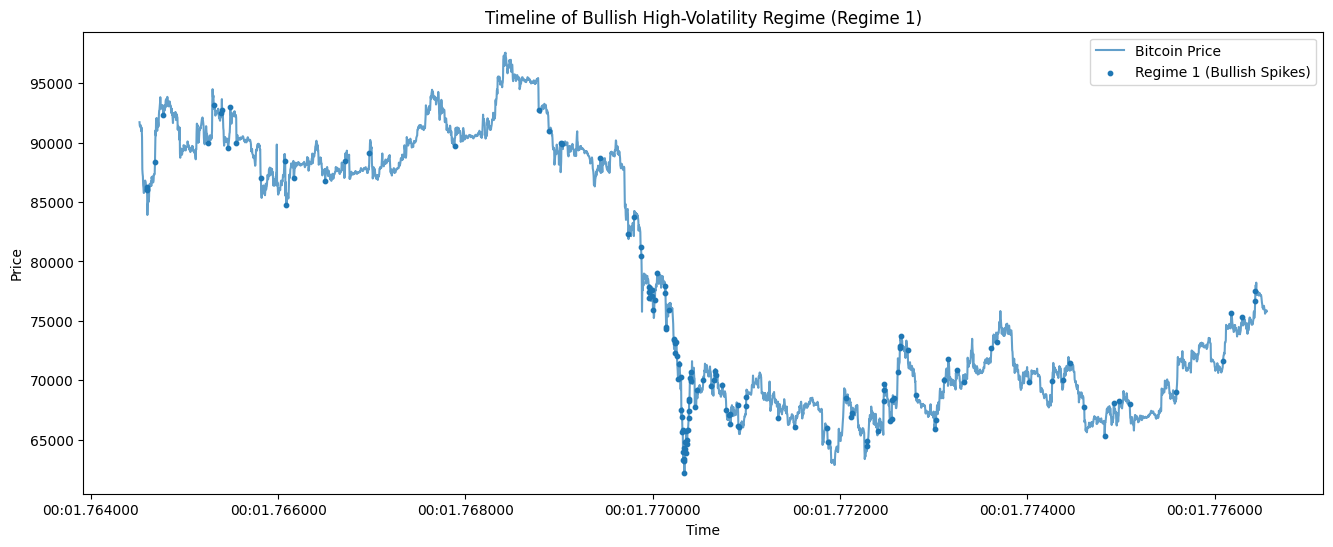

In [ ]:
# TIMELINE: REGIME 1 SPIKES
df_plot = df.iloc[::50]  # every 50th point
plt.figure(figsize=(16,6))

# Plot price
plt.plot(df_plot["Timestamp"], df_plot["Close"], label="Bitcoin Price", alpha=0.7)

# Highlight Regime 1 points
regime1 = df_plot[df_plot["regime"] == 1]

plt.scatter(
    regime1["Timestamp"],
    regime1["Close"],
    s=10,
    label="Regime 1 (Bullish Spikes)",
    marker='o'
)

plt.title("Timeline of Bullish High-Volatility Regime (Regime 1)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

The plot shows the Bitcoin price over time with points belonging to Regime 1 highlighted, allowing you to see where this specific market condition occurs along the timeline. The line represents the overall price movement, while the overlaid dots mark time steps classified as Regime 1 (interpreted as a high-volatility or "bullish spike" regime). From the visualization, these points tend to cluster around periods of sharp price movements and local instability, rather than being evenly distributed. Notably, many Regime 1 points appear during rapid upward moves or sudden fluctuations, but they are also present around turning points and volatile transitions, not just clean bullish trends. This suggests that Regime 1 is capturing intense market activity and volatility, rather than purely upward price direction. Overall, the plot validates that your clustering is picking up meaningful temporal patterns, with Regime 1 aligning closely with dynamic, high-energy phases of the market rather than stable periods.

In [ ]:
signal = df["volatility_10"].values

This converts the volatility_10 column into a NumPy array to treat it as a 1D time-series signal for further analysis.

# 12. Volatility Regime Detection Using Binary Segmentation Change Point Analysis
I used Binary Segmentation from ruptures to identify change points in the volatility signal, i.e., points where the statistical behavior of the market shifts. The method (model="l2") detects changes in the mean using squared error, which is well-suited for continuous signals like volatility. The algorithm recursively splits the time series into segments that are internally consistent but different from each other. By setting n_bkps = 20, you instruct the model to return 20 breakpoints (21 segments), which is a modeling choice to balance capturing meaningful regime shifts without overfitting noise- too few breakpoints would miss important changes, while too many would detect random fluctuations. The resulting breakpoints indicate the time indices where volatility regimes change.

In [ ]:
# Binary Segmentation model
model = "l2"

algo = rpt.Binseg(model=model).fit(signal)

# Number of breakpoints
n_bkps = 20

breakpoints = algo.predict(n_bkps=n_bkps)

print(breakpoints[:10])

[25690, 27615, 86125, 88065, 88975, 89250, 89260, 89280, 94715, 95010]


Several breakpoints are very close together (e.g., 88975-89280) suggests a period of rapid regime instability or noisy fluctuations, where the model detects multiple small shifts in a short span of time.

# 13. Detection of Structural Breaks in Bitcoin Price Dynamics Using Change Point Analysis

This visualization shows Bitcoin's closing price over time, with vertical dashed lines marking statistically detected change points in the time series. These breakpoints segment the price history into distinct regimes where the underlying statistical behavior (such as trend or volatility structure) shifts. The method highlights periods where the market transitions between different phases, such as stable growth, sharp rallies, or heightened turbulence, without relying on predefined labels. By overlaying change points on the raw price series, the plot provides an intuitive way to identify structural shifts in market behavior that may not be immediately visible from price movements alone.

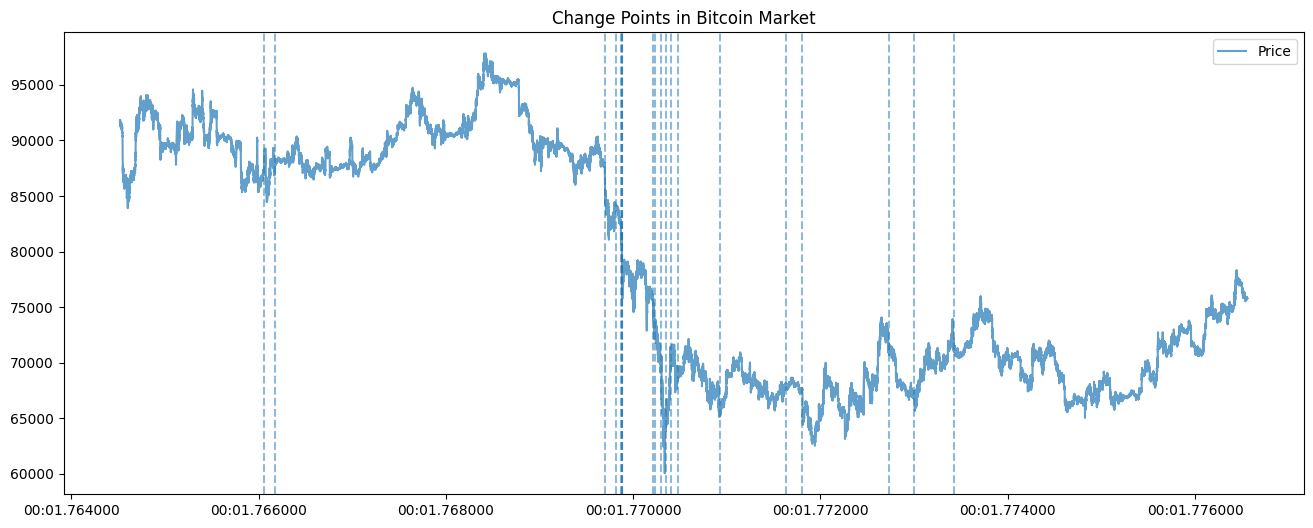

In [ ]:
plt.figure(figsize=(16,6))

# Price plot
plt.plot(df["Timestamp"], df["Close"], label="Price", alpha=0.7)

# Plot change points
for bp in breakpoints:
    if bp < len(df):
        plt.axvline(df["Timestamp"].iloc[bp], linestyle='--', alpha=0.5)

plt.title("Change Points in Bitcoin Market")
plt.legend()
plt.show()

The plot shows the price of Bitcoin over time with detected change points marked as vertical dashed lines, indicating moments where the underlying statistical behavior of the price shifts significantly. Rather than highlighting isolated anomalies, the plot identifies boundaries between different market regimes. Initially, the price remains relatively high (around 90k-95k) with moderate fluctuations, and the presence of only a few change points suggests stable and consistent market behavior. In the middle of the plot, a dense cluster of change points appears around a sharp price drop, signaling a period of rapid structural changes, this corresponds to a market shock or crash where trends, volatility, and price levels shift quickly. After this drop, the price stabilizes in the 65k-75k range, and the change points become more spaced out, indicating the emergence of a new, relatively stable regime distinct from the initial phase. Overall, fewer change points reflect stability, clustered change points indicate instability or transition, and spaced-out points suggest a new steady state. This demonstrates that the change-point detection model is effectively capturing regime shifts rather than noise, with dense regions highlighting periods of high uncertainty where typical predictive models may become less reliable.

# 14. Identification of Regime-Specific Market Phases in Bitcoin Using Change Point Detection

The plot visualizes Bitcoin's closing price over time while highlighting a specific market regime (Regime 1) identified through clustering on market features. The shaded region indicates periods where the model classifies the market as being in the same regime, helping isolate segments with similar statistical or behavioral characteristics. Change points are also overlaid as vertical dashed lines, marking structural shifts in the time series where the market transitions between different regimes. Together, this combines clustering (to define market states) and change point detection (to identify transitions), allowing a clearer interpretation of how Bitcoin's behavior evolves over time.

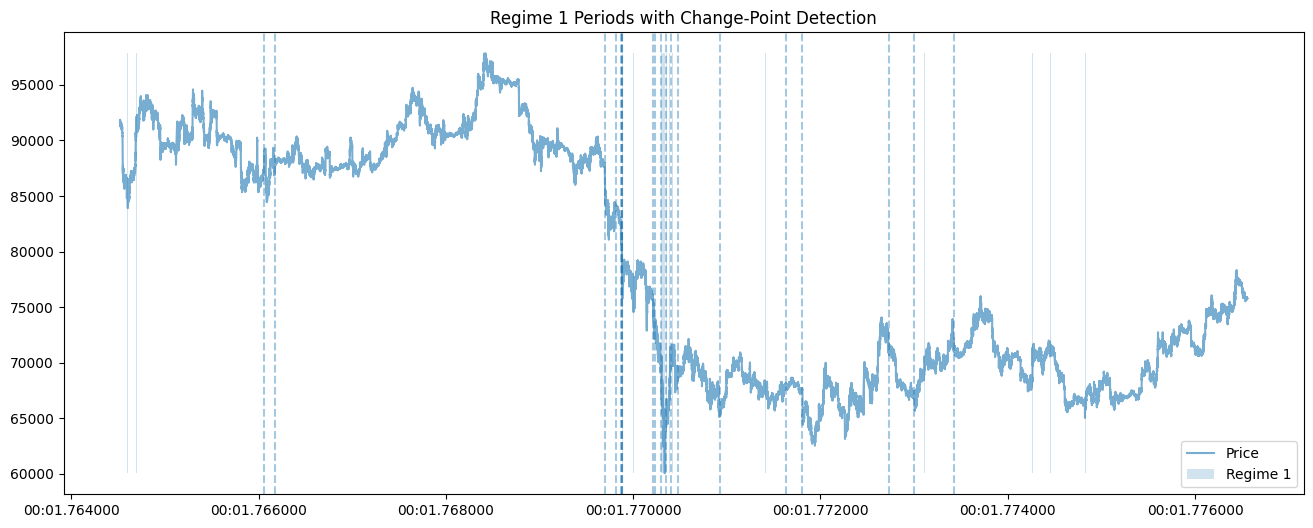

In [ ]:
plt.figure(figsize=(16,6))

# Price
plt.plot(df["Timestamp"], df["Close"], alpha=0.6, label="Price")

# Highlight Regime 1
mask = df["regime"] == 1
plt.fill_between(
    df["Timestamp"],
    df["Close"].min(),
    df["Close"].max(),
    where=mask,
    alpha=0.2,
    label="Regime 1"
)

# Change points
for bp in breakpoints:
    if bp < len(df):
        plt.axvline(df["Timestamp"].iloc[bp], linestyle='--', alpha=0.4)

plt.title("Regime 1 Periods with Change-Point Detection")
plt.legend()
plt.show()

The plot focuses specifically on Regime 1 to determine whether the price behavior within that single cluster is actually stable or if it undergoes meaningful internal shifts over time. By isolating Regime 1 (shown by the shaded region), it removes noise from other market conditions and examines only one type of behavior identified by your clustering model. The blue line tracks how the price evolves within this regime, capturing trends, drops, and recoveries. The key insight comes from the vertical dashed lines, which mark change points-moments where the statistical properties of the price series, such as mean, variance, or trend, shift significantly. These indicate that even within a single regime, the market is not uniform. For instance, clusters of closely spaced change points (like around sharp drops) highlight periods of instability and rapid structural change, while sparse regions suggest relative stability. Conceptually, this shows that clustering provides a coarse-grained segmentation of market behavior, but change-point detection refines it by revealing sub-regimes within each cluster. The main takeaway is that Regime 1 is not homogeneous-important dynamics such as volatility spikes or directional shifts still occur within it, and these finer structural changes would be missed without change-point analysis.

# 15. Regime Transition Probability Matrix for Market State Dynamics

This converts raw regime transition counts into a normalized probability matrix that describes how the market moves between different states. Each row corresponds to a current regime, and each value in that row represents the probability of transitioning to another regime (including remaining in the same one). By dividing each row by its total number of transitions, the matrix is scaled so that all probabilities sum to 1 per regime. This representation makes it easier to interpret market behavior as a stochastic process, highlighting regime stability and the likelihood of switching between different market conditions over time.

In [ ]:
transition_prob = transitions.div(transitions.sum(axis=1), axis=0)
print(transition_prob)

regime         0         1         2         3
regime                                        
0.0     0.772214  0.018286  0.133212  0.076289
1.0     0.140217  0.488995  0.000000  0.370788
2.0     0.066165  0.000297  0.928582  0.004957
3.0     0.472210  0.221201  0.003780  0.302809


Regime 0 is relatively stable, with a high probability (≈77%) of remaining in the same state, but it can occasionally shift to regimes 2 or 3. Regime 1 is less stable, with only about a 49% chance of persistence and a significant likelihood (≈37%) of transitioning to regime 3, indicating more dynamic or uncertain behavior. Regime 2 is highly stable, with a very strong self-transition probability (≈93%), suggesting it represents a consistent and dominant market condition. In contrast, regime 3 is the most volatile or transitional state, as it has a lower probability of staying (≈30%) and a high chance (≈47%) of moving back to regime 0, along with moderate transitions to regime 1. Overall, regimes with high self-transition probabilities (like 2 and 0) indicate stable market phases, while regimes with more distributed probabilities (like 1 and especially 3) reflect periods of higher uncertainty and frequent structural shifts.

# 16. Visualization of Market Regime Transition Probabilities Using Heatmap

I visualized the regime transition probability matrix as a heatmap to make the underlying Markov-style dynamics easier to interpret. Each cell in the heatmap represents the probability of moving from one market regime (row) to another (column), including the probability of staying in the same regime. The color intensity (using the "Blues" colormap) encodes the strength of these probabilities, while numerical annotations provide exact values for clarity. This visual format helps quickly identify stable regimes (high self-transition probabilities) and frequent regime shifts, making the structure of market state transitions more interpretable than a raw matrix.

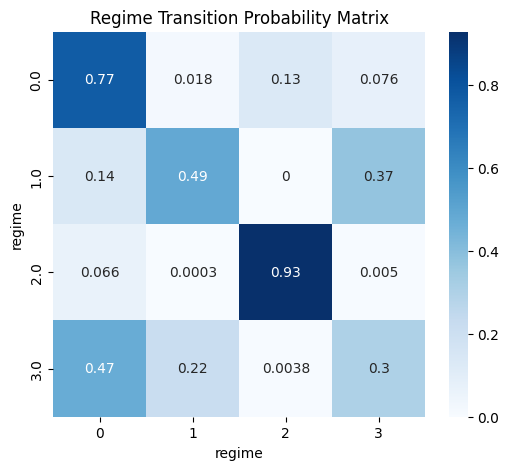

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(transition_prob, annot=True, cmap="Blues")
plt.title("Regime Transition Probability Matrix")
plt.show()

The heatmap shows how likely the market is to stay in or switch between the four regimes over time, essentially capturing the dynamics of regime persistence and transition. Each row represents the current regime, and each column represents the next regime, with the values indicating transition probabilities. The diagonal values are the most important, they show how "sticky" each regime is. For example, Regime 2 has a very high self-transition probability (0.93), meaning it is highly stable and, once entered, tends to persist for long periods. In contrast, Regime 1 (0.49) and Regime 3 (0.30) are much less stable, indicating frequent transitions out of these states. Looking at off-diagonal values, Regime 3 has a strong tendency to move to Regime 0 (0.47), suggesting a common pathway or recovery pattern between these states. Similarly, Regime 1 often transitions to Regime 3 (0.37), indicating a possible progression between those behaviors. Overall, the matrix reveals that not all regimes are equally stable, some represent persistent market conditions while others are more transient and act as bridges between states, providing deeper insight into how market behavior evolves over time beyond just static clustering.

# 17. Bull vs Bear Regime Comparison

I compared key features between:
- Regime 1 (Bullish / high volatility)
- Regime 3 (Bearish / declining phase)


In [ ]:
r1 = df[df["regime"] == 1]
r3 = df[df["regime"] == 3]

compare = pd.DataFrame({
    "Regime 1 (Bull)": r1[features].mean(),
    "Regime 3 (Bear)": r3[features].mean()
})

print(compare)

               Regime 1 (Bull)  Regime 3 (Bear)
log_return            0.001264        -0.001390
volatility_10         0.001739         0.001227
volatility_30         0.001631         0.001180
volume_change         0.647668         1.033016
price_range         176.822283       144.216304
bb_width              0.006775         0.004406


The table compares the average behavior of Bitcoin during two market regimes-Regime 1 (Bull) and Regime 3 (Bear)-and highlights how market dynamics change between upward and downward phases. In the bull regime, returns are slightly positive (log_return ≈ 0.001264), while in the bear regime they turn negative (≈ -0.001390), clearly reflecting upward vs. downward price pressure. Volatility is relatively similar in both regimes but slightly higher in the bull phase for shorter windows, suggesting active upward movement with fluctuations. A key difference appears in volume_change, where the bear regime shows a much higher value (≈ 1.03 vs 0.65), indicating heavier trading activity during downturns, often associated with panic selling or repositioning. The price_range is wider in the bull regime, meaning prices move more broadly upward, while the bear regime shows a tighter range, consistent with downward consolidation or sharper declines. Finally, Bollinger Band width (bb_width) is higher in the bull regime, suggesting stronger trend expansion and momentum, whereas the lower value in the bear regime reflects contraction and weakening trend strength. Overall, the table shows that bull markets are characterized by positive returns, broader price movement, and expansion signals, while bear markets show negative returns, higher volume stress, and more constrained price behavior.

# 18. Temporal Trend of Anomaly Density in Market Behavior Using Rolling Average

I analyzed how the frequency of anomalies evolves over time by computing a rolling average of the binary anomaly indicator (final_anomaly) using a window size of 500 observations. A time index is first created to represent sequential ordering of data points. The rolling mean smooths short-term fluctuations and reveals broader trends in anomaly occurrence, effectively showing periods of higher or lower abnormal market activity. The resulting plot visualizes this anomaly density over time, while vertical lines mark previously detected change points to help relate shifts in anomaly behavior to structural changes in the market.

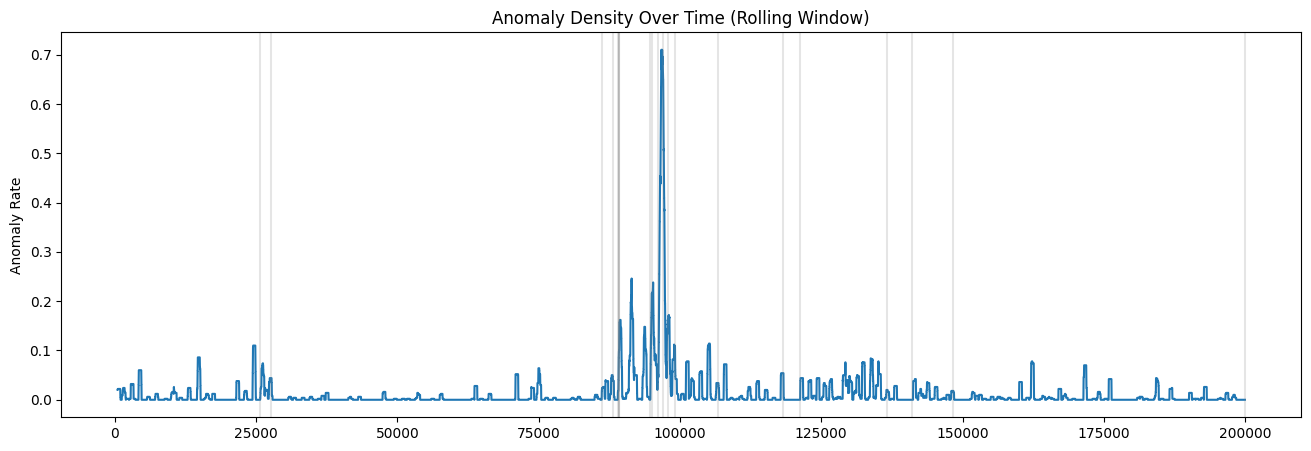

In [ ]:
df["time_index"] = np.arange(len(df))
rolling_anom = df["final_anomaly"].rolling(500).mean()


plt.figure(figsize=(16,5))
plt.plot(df["time_index"], rolling_anom)
plt.title("Anomaly Density Over Time (Rolling Window)")
plt.ylabel("Anomaly Rate")
for bp in breakpoints:
    plt.axvline(bp, color='gray', alpha=0.2)
plt.show()

This plot shows how the frequency of anomalies evolves over time using a rolling window, helping identify periods where unusual behavior becomes concentrated rather than isolated. The blue line represents the anomaly rate, i.e., the proportion of points flagged as anomalous within each window, so higher values indicate bursts of instability or irregular market behavior. Most of the timeline exhibits very low anomaly density, suggesting that the system is generally stable with only occasional outliers. However, there is a pronounced spike around the middle of the series (near ~90k-100k), where the anomaly rate sharply increases, indicating a sustained period of abnormal activity rather than random noise. The vertical gray lines (change points) cluster heavily around this region, reinforcing that this spike aligns with a structural shift in the underlying process. After this period, the anomaly rate declines again but remains slightly more active than earlier segments, suggesting residual instability. Overall, the plot reveals that anomalies are not uniformly distributed, they occur in bursts tied to regime shifts or major events, highlighting that extreme behavior in the system is temporally concentrated rather than random.

Taken together, these analyses show that market behavior is structured at multiple levels rather than being uniform or random. The regime clustering provides a coarse segmentation, identifying distinct types of market conditions, but the transition matrix reveals that these regimes differ significantly in stability - some are highly persistent (like Regime 2), while others are short-lived and act as transition states (like Regime 1 and 3). Looking deeper, the change-point analysis demonstrates that even within a single regime, the price series is not homogeneous; it breaks into smaller sub-periods with distinct statistical properties, especially during volatile events. This is reinforced by the anomaly density plot, which shows that unusual behavior is not evenly spread over time but instead occurs in concentrated bursts, often aligning with structural breaks. Overall, the key insight is that market dynamics operate hierarchically: regimes capture broad patterns, transitions explain how the system evolves between them, and change points and anomalies expose fine-grained instability within those regimes-highlighting that meaningful market events are localized in time and cannot be fully understood through clustering alone.

## Key Takeaways

- **Markets are not stationary:**  
  Bitcoin price behavior shows clear structural breaks, meaning trends and volatility change over time rather than remaining constant.

- **Distinct market regimes exist:**  
  Clustering reveals multiple regimes such as high-volatility and low-volatility states, indicating that market behavior naturally segments into different phases.

- **Regime switching is probabilistic:**  
  The transition matrix shows that some regimes are more stable (high probability of staying in the same state), while others are more likely to transition, capturing market uncertainty.

- **Change points reflect structural shifts:**  
  Detected change points align with shifts in price dynamics, helping identify when the market transitions between different behavioral phases.

- **Anomalies cluster over time:**  
  Rolling anomaly analysis shows that anomalies are concentrated in specific periods rather than evenly distributed, indicating bursts of unusual market activity.

- **Market instability is episodic:**  
  High anomaly density often coincides with regime changes, suggesting that instability occurs in waves rather than continuously.

- **Multi-method approach improves insight:**  
  Combining change point detection, clustering, transition probabilities, and anomaly detection provides a more complete and interpretable understanding of market dynamics.

## **Conclusion**
This project set out to answer whether meaningful, interpretable structure exists in Bitcoin's high-frequency price data - and the answer is clearly yes. Rather than treating the market as a single noisy process, the multi-method pipeline revealed that Bitcoin dynamics operate at multiple levels simultaneously.
K-Means clustering identified four distinct market regimes with meaningfully different volatility and return profiles. The ensemble anomaly detector (Isolation Forest + Z-score) flagged roughly 1.37% of observations as anomalous - and critically, these anomalies were not random. They concentrated almost entirely in Regime 1, the high-volatility bullish phase, while stable regimes (0 and 2) had zero anomaly presence. SHAP analysis added a counterintuitive but important insight: in Bitcoin markets, unusually low volatility is a stronger anomaly signal than extreme spikes, reflecting that high volatility is actually the norm in crypto. Regime transition probabilities confirmed that some states (Regime 2, ~93% self-transition) are highly persistent, while others (Regime 3, ~30%) act as short-lived bridges between conditions. Finally, binary segmentation change-point detection showed that structural breaks cluster around the major mid-series price crash, and that rolling anomaly density spikes coincide with these transitions - confirming that market instability is episodic, not continuous.
Taken together, the clearest takeaway is this: Bitcoin market behavior is better described by regime transitions than by any single trend or indicator. Anomalies and volatility spikes are not isolated events - they are symptoms of the market moving between states.

## **Limitations**
1. No ground truth for regimes - K-Means clustering is unsupervised, meaning the four regimes are defined by the algorithm, not by any external label.
2. Change-point count is manually specified.
Binary segmentation requires a fixed n_bkps=20. This is an arbitrary modeling.
3. Regimes are not predictive - The clustering and change-point detection are descriptive, not predictive. They explain what happened, but the model has no mechanism to forecast when the next regime transition will occur or how long a current regime will persist.

## **Future Work**
1. Dynamic / online clustering - Replace static K-Means with an online or sliding-window clustering approach to detect regime changes in real time rather than retrospectively.
2. Incorporating external signals.
Enrich the feature set with on-chain data (e.g., active addresses, exchange inflows/outflows), funding rates, or sentiment scores from social media. These could help distinguish between technically similar regimes that have different underlying drivers.
3. Regime-conditioned forecasting - Use the identified regime labels as context for a downstream forecasting model (e.g., an LSTM or transformer trained separately per regime). The hypothesis is that regime-aware models would outperform a single global model on volatile segments.
4. Extending to other assets - Apply the same pipeline to Ethereum, other altcoins, or traditional asset classes (S&P 500, gold) to test whether the same regime structure holds, or whether the "unusual calmness = anomaly" finding is specific to Bitcoin's volatility profile.

In [3]:
!pip freeze > requirements.txt